In [1]:
import math
import os
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split

print("All imports successful.")

All imports successful.


In [ ]:

def compute_mean(values):
    total = 0.0
    count = 0
    for v in values:
        total += v
        count += 1
    if count == 0:
        return 0.0
    return total / count


def compute_variance(values):
    mean = compute_mean(values)
    total = 0.0
    count = 0
    for v in values:
        total += (v - mean) ** 2
        count += 1
    if count == 0:
        return 0.0
    return total / count


def compute_accuracy(y_true, y_pred):
   
    total = len(y_true)
    if total == 0:
        return 0.0
    correct = 0
    for i in range(total):
        if y_true[i] == y_pred[i]:
            correct += 1
    return correct / total


def safe_log(x):
   
    if x <= 0:
        return float('-inf')
    return math.log(x)


def get_unique_classes(y):
    classes = []
    for label in y:
        if label not in classes:
            classes.append(label)
    return classes


def separate_by_class(X, y):
    separated = {}
    for i in range(len(y)):
        label = y[i]
        if label not in separated:
            separated[label] = []
        separated[label].append(X[i])
    return separated


def get_column(X, col_index):
    return [row[col_index] for row in X]


sample_vals = [2.0, 4.0, 4.0, 4.0, 5.0, 5.0, 7.0, 9.0]
print(f"compute_mean    : {compute_mean(sample_vals):.4f}  (expected 5.0)")
print(f"compute_variance: {compute_variance(sample_vals):.4f}  (expected 4.0)")
print(f"compute_accuracy: {compute_accuracy([0,1,1,0],[0,1,0,0]):.4f}  (expected 0.75)")

compute_mean    : 5.0000  (expected 5.0)
compute_variance: 4.0000  (expected 4.0)
compute_accuracy: 0.7500  (expected 0.75)


In [ ]:

FEATURE_COLS = ['Length', 'Diameter', 'Height',
                'Whole weight', 'Shucked weight', 'Viscera weight', 'Shell weight']

def rings_to_class(r):
    if r <= 8:     return 'Young'
    elif r <= 11:  return 'Adult'
    else:          return 'Old'


def load_abalone(csv_path='abalone.csv'):
    df = pd.read_csv(csv_path)
    df = df[FEATURE_COLS + ['Rings']].copy()
    df['Class'] = df['Rings'].apply(rings_to_class)
    df = df.drop(columns=['Rings'])
    return df


df_abalone = load_abalone('abalone.csv')
print(f"Dataset shape : {df_abalone.shape}")
print(f"Class counts  :\n{df_abalone['Class'].value_counts()}")
df_abalone.head()

Dataset shape : (4177, 8)
Class counts  :
Class
Adult    1810
Young    1407
Old       960
Name: count, dtype: int64


,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Class
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,Old
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,Young
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,Adult
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,Adult
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,Young


In [ ]:
train_df, test_df = train_test_split(df_abalone, test_size=0.2, random_state=42)

X_train_raw = train_df[FEATURE_COLS].values.tolist()
y_train     = train_df['Class'].tolist()
X_test_raw  = test_df[FEATURE_COLS].values.tolist()
y_test      = test_df['Class'].tolist()

print(f"Train samples : {len(X_train_raw)}")
print(f"Test  samples : {len(X_test_raw)}")

Train samples : 3341
Test  samples : 836


In [ ]:
classes_gnb = get_unique_classes(y_train)
separated   = separate_by_class(X_train_raw, y_train)
n_train     = len(y_train)
n_features  = len(FEATURE_COLS)

gnb_priors = {}
gnb_means  = {}
gnb_vars   = {}

for c in classes_gnb:
    rows = separated[c]
    gnb_priors[c] = len(rows) / n_train
    gnb_means[c]  = [compute_mean(get_column(rows, f))     for f in range(n_features)]
    gnb_vars[c]   = [compute_variance(get_column(rows, f)) for f in range(n_features)]

print("Class priors:")
for c in classes_gnb:
    print(f"  {c:6s}: {gnb_priors[c]:.4f}")

Class priors:
  Adult : 0.4298
  Young : 0.3376
  Old   : 0.2326


In [ ]:
def gaussian_pdf_scalar(x, mean, var):
   
    if var <= 0:
        var = 1e-9
    exponent = math.exp(-((x - mean) ** 2) / (2 * var))
    return (1.0 / math.sqrt(2 * math.pi * var)) * exponent


def log_gaussian_pdf(x, mean, var):
    
    if var <= 0:
        var = 1e-9
    return -0.5 * math.log(2 * math.pi * var) - ((x - mean) ** 2) / (2 * var)


print("gaussian_pdf_scalar(0, 0, 1) =", round(gaussian_pdf_scalar(0, 0, 1), 6))
print("log_gaussian_pdf  (0, 0, 1) =", round(log_gaussian_pdf(0, 0, 1),    6))

gaussian_pdf_scalar(0, 0, 1) = 0.398942
log_gaussian_pdf  (0, 0, 1) = -0.918939


In [ ]:
def gnb_predict_nolog(sample):
    best_class = None
    best_score = -1.0
    for c in classes_gnb:
        score = gnb_priors[c]
        for f in range(n_features):
            score *= gaussian_pdf_scalar(sample[f], gnb_means[c][f], gnb_vars[c][f])
        if score > best_score:
            best_score = score
            best_class = c
    return best_class


def gnb_predict(sample):
   
    best_class = None
    best_log   = float('-inf')
    for c in classes_gnb:
        log_score = safe_log(gnb_priors[c])
        for f in range(n_features):
            log_score += log_gaussian_pdf(sample[f], gnb_means[c][f], gnb_vars[c][f])
        if log_score > best_log:
            best_log   = log_score
            best_class = c
    return best_class


def gnb_predict_prob(sample):
  
    log_scores = {}
    for c in classes_gnb:
        log_score = safe_log(gnb_priors[c])
        for f in range(n_features):
            log_score += log_gaussian_pdf(sample[f], gnb_means[c][f], gnb_vars[c][f])
        log_scores[c] = log_score
    max_log = max(log_scores.values())
    raw     = {c: math.exp(log_scores[c] - max_log) for c in classes_gnb}
    total   = sum(raw.values())
    return {c: raw[c] / total for c in classes_gnb}


y_pred_nolog = [gnb_predict_nolog(x) for x in X_test_raw]
y_pred_log   = [gnb_predict(x)       for x in X_test_raw]

acc_nolog = compute_accuracy(y_test, y_pred_nolog)
acc_log   = compute_accuracy(y_test, y_pred_log)

print("=" * 55)
print("Gaussian Naive Bayes — Test Set Accuracy")
print("=" * 55)
print(f"  Without log probabilities : {acc_nolog:.4f}  ({acc_nolog*100:.2f}%)")
print(f"  With    log probabilities : {acc_log:.4f}  ({acc_log*100:.2f}%)")
print(f"  Test samples              : {len(y_test)}")

Gaussian Naive Bayes — Test Set Accuracy
  Without log probabilities : 0.5658  (56.58%)
  With    log probabilities : 0.5658  (56.58%)
  Test samples              : 836


In [ ]:
sample_abalone = X_test_raw[0]
true_label     = y_test[0]

print("Feature values  :", dict(zip(FEATURE_COLS, sample_abalone)))
print("True class      :", true_label)
print("Predicted class :", gnb_predict(sample_abalone))
print("\nClass probabilities:")
for cls, prob in sorted(gnb_predict_prob(sample_abalone).items()):
    print(f"  {cls:6s}: {prob:.6f}  ({prob*100:.2f}%)")

Feature values  : {'Length': 0.605, 'Diameter': 0.455, 'Height': 0.16, 'Whole weight': 1.1035, 'Shucked weight': 0.421, 'Viscera weight': 0.3015, 'Shell weight': 0.325}
True class      : Adult
Predicted class : Adult

Class probabilities:
  Adult : 0.598525  (59.85%)
  Old   : 0.401475  (40.15%)
  Young : 0.000001  (0.00%)


In [ ]:
def preprocess(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text.split()

print(preprocess("Hello, World! This is a TEST."))

['hello', 'world', 'this', 'is', 'a', 'test']


In [ ]:
def build_smart_vocabulary(train_texts, min_freq=5):
    word_counts = {}
    for text in train_texts:
        for token in preprocess(text):
            word_counts[token] = word_counts.get(token, 0) + 1
    vocab = {}
    idx = 0
    for word, count in word_counts.items():
        if count >= min_freq:
            vocab[word] = idx
            idx += 1
    return vocab, word_counts

def build_bow_matrix(texts, vocab):
    matrix = np.zeros((len(texts), len(vocab)), dtype=np.float32)
    for i, text in enumerate(texts):
        for token in preprocess(text):
            if token in vocab:
                matrix[i, vocab[token]] += 1
    return matrix


def load_imdb_data(base_path, split, limit=2000):
    texts, labels = [], []
    for sentiment in ['pos', 'neg']:
        folder = os.path.join(base_path, split, sentiment)
        label  = 1 if sentiment == 'pos' else 0
        if not os.path.exists(folder):
            continue
        for fname in os.listdir(folder)[:limit]:
            if fname.endswith('.txt'):
                with open(os.path.join(folder, fname), 'r', encoding='utf-8') as f:
                    texts.append(f.read())
                    labels.append(label)
    return texts, labels


IMDB_PATH = 'aclImdb'   
LIMIT     = 2000        
MIN_FREQ  = 10

print("Loading training data...")
train_texts, train_labels = load_imdb_data(IMDB_PATH, 'train', limit=LIMIT)
print("Loading test data...")
test_texts,  test_labels  = load_imdb_data(IMDB_PATH, 'test',  limit=LIMIT)
print(f"Train reviews : {len(train_texts)}")
print(f"Test  reviews : {len(test_texts)}")

Loading training data...
Loading test data...
Train reviews : 4000
Test  reviews : 4000


In [11]:
print("Building vocabulary...")
vocab, word_counts_all = build_smart_vocabulary(train_texts, min_freq=MIN_FREQ)
print(f"Vocabulary size : {len(vocab)} words (min_freq={MIN_FREQ})")

print("Building BoW matrices...")
X_train_bow = build_bow_matrix(train_texts, vocab)
X_test_bow  = build_bow_matrix(test_texts,  vocab)

y_train_imdb = np.array(train_labels)
y_test_imdb  = np.array(test_labels)

print(f"Train BoW shape : {X_train_bow.shape}  ({X_train_bow.nbytes/1e6:.1f} MB)")
print(f"Test  BoW shape : {X_test_bow.shape}")

Building vocabulary...
Vocabulary size : 6406 words (min_freq=10)
Building BoW matrices...
Train BoW shape : (4000, 6406)  (102.5 MB)
Test  BoW shape : (4000, 6406)


In [ ]:
ALPHA        = 1
classes_mnb  = [0, 1]
n_train_imdb = len(y_train_imdb)
vocab_size   = len(vocab)

mnb_log_prior = {}
for c in classes_mnb:
    count_c = int((y_train_imdb == c).sum())
    mnb_log_prior[c] = safe_log(count_c / n_train_imdb)

mnb_log_likelihood = {}
for c in classes_mnb:
    wc    = X_train_bow[y_train_imdb == c].sum(axis=0)
    total = wc.sum() + ALPHA * vocab_size
    mnb_log_likelihood[c] = np.log((wc + ALPHA) / total)

print("Multinomial NB model trained.")
print(f"  Log prior (pos): {mnb_log_prior[1]:.4f}")
print(f"  Log prior (neg): {mnb_log_prior[0]:.4f}")

Multinomial NB model trained.
  Log prior (pos): -0.6931
  Log prior (neg): -0.6931


In [ ]:
def mnb_predict(bow_vector):
    best_class = None
    best_log   = float('-inf')
    for c in classes_mnb:
        log_score = mnb_log_prior[c] + float(np.dot(bow_vector, mnb_log_likelihood[c]))
        if log_score > best_log:
            best_log   = log_score
            best_class = c
    return best_class


def mnb_predict_prob(bow_vector):
    log_scores = {
        c: mnb_log_prior[c] + float(np.dot(bow_vector, mnb_log_likelihood[c]))
        for c in classes_mnb
    }
    max_log = max(log_scores.values())
    raw     = {c: math.exp(log_scores[c] - max_log) for c in classes_mnb}
    total   = sum(raw.values())
    return {c: raw[c] / total for c in classes_mnb}


def mnb_predict_text(text):
    bow = np.zeros(vocab_size, dtype=np.float32)
    for token in preprocess(text):
        if token in vocab:
            bow[vocab[token]] += 1
    return mnb_predict(bow), mnb_predict_prob(bow)



y_pred_mnb = np.array([mnb_predict(X_test_bow[i]) for i in range(len(y_test_imdb))])
acc_mnb    = compute_accuracy(y_test_imdb.tolist(), y_pred_mnb.tolist())

print("=" * 55)
print("Multinomial Naive Bayes — Test Set Accuracy")
print("=" * 55)
print(f"  Test accuracy : {acc_mnb:.4f}  ({acc_mnb*100:.2f}%)")
print(f"  Test samples  : {len(y_test_imdb)}")
print(f"  Correct       : {int(acc_mnb * len(y_test_imdb))} / {len(y_test_imdb)}")

Multinomial Naive Bayes — Test Set Accuracy
  Test accuracy : 0.8017  (80.17%)
  Test samples  : 4000
  Correct       : 3207 / 4000


In [ ]:

demo_reviews = [
    "This movie was absolutely fantastic! Great acting and a brilliant story.",
    "Terrible film. Boring, predictable, and a complete waste of time.",
    "Decent movie, some good moments but the ending was disappointing."
]
print("=" * 60)
print("Demo Sentiment Predictions")
print("=" * 60)
for review in demo_reviews:
    label, probs = mnb_predict_text(review)
    sentiment = 'POSITIVE' if label == 1 else 'NEGATIVE'
    print(f"\nReview   : {review[:65]}")
    print(f"Predicted: {sentiment}")
    print(f"Probs    : Positive={probs[1]:.4f}  Negative={probs[0]:.4f}")

Demo Sentiment Predictions

Review   : This movie was absolutely fantastic! Great acting and a brilliant
Predicted: POSITIVE
Probs    : Positive=0.8931  Negative=0.1069

Review   : Terrible film. Boring, predictable, and a complete waste of time.
Predicted: NEGATIVE
Probs    : Positive=0.0007  Negative=0.9993

Review   : Decent movie, some good moments but the ending was disappointing.
Predicted: NEGATIVE
Probs    : Positive=0.0339  Negative=0.9661


In [ ]:

print("=" * 55)
print("Gaussian NB — Log vs No-Log")
print("=" * 55)
print(f"  Without log probs : {acc_nolog*100:.2f}%")
print(f"  With    log probs : {acc_log*100:.2f}%")
disagree_gnb = sum(1 for a, b in zip(y_pred_nolog, y_pred_log) if a != b)
print(f"  Disagreements     : {disagree_gnb} samples flipped due to underflow")
print()


def mnb_predict_nolog(bow_vector):
    best_class = None
    best_score = -1.0
    for c in classes_mnb:
        score = math.exp(mnb_log_prior[c])
        for idx in range(len(bow_vector)):
            if bow_vector[idx] > 0:
                p = math.exp(float(mnb_log_likelihood[c][idx]))
                score *= p ** bow_vector[idx]
                if score == 0:
                    break   
        if score > best_score:
            best_score = score
            best_class = c
    return best_class


SUBSET = 200
y_pred_mnb_nolog = [mnb_predict_nolog(X_test_bow[i]) for i in range(SUBSET)]
y_pred_mnb_log_s = [mnb_predict(X_test_bow[i])       for i in range(SUBSET)]

acc_mnb_nolog = compute_accuracy(y_test_imdb[:SUBSET].tolist(), y_pred_mnb_nolog)
acc_mnb_log_s = compute_accuracy(y_test_imdb[:SUBSET].tolist(), y_pred_mnb_log_s)

print("=" * 55)
print(f"Multinomial NB — Log vs No-Log (first {SUBSET} samples)")
print("=" * 55)
print(f"  Without log probs : {acc_mnb_nolog*100:.2f}%")
print(f"  With    log probs : {acc_mnb_log_s*100:.2f}%")
disagree_mnb = sum(1 for a, b in zip(y_pred_mnb_nolog, y_pred_mnb_log_s) if a != b)
print(f"  Disagreements     : {disagree_mnb} samples flipped due to underflow")

Gaussian NB — Log vs No-Log
  Without log probs : 56.58%
  With    log probs : 56.58%
  Disagreements     : 0 samples flipped due to underflow

Multinomial NB — Log vs No-Log (first 200 samples)
  Without log probs : 0.00%
  With    log probs : 70.00%
  Disagreements     : 140 samples flipped due to underflow


In [ ]:

summary = pd.DataFrame({
    'Classifier'     : ['Gaussian NB (no-log)', 'Gaussian NB (log)',
                        f'Multinomial NB (no-log, n={SUBSET})', 'Multinomial NB (log, full)'],
    'Accuracy (%)'   : [round(acc_nolog*100,2), round(acc_log*100,2),
                        round(acc_mnb_nolog*100,2), round(acc_mnb*100,2)],
    'Underflow risk' : ['High','None','Very High','None'],
    'Recommended'    : ['No','Yes','No','Yes'],
})
summary

,Classifier,Accuracy (%),Underflow risk,Recommended
0,Gaussian NB (no-log),56.58,High,No
1,Gaussian NB (log),56.58,None,Yes
2,"Multinomial NB (no-log, n=200)",0.00,Very High,No
3,"Multinomial NB (log, full)",80.17,None,Yes


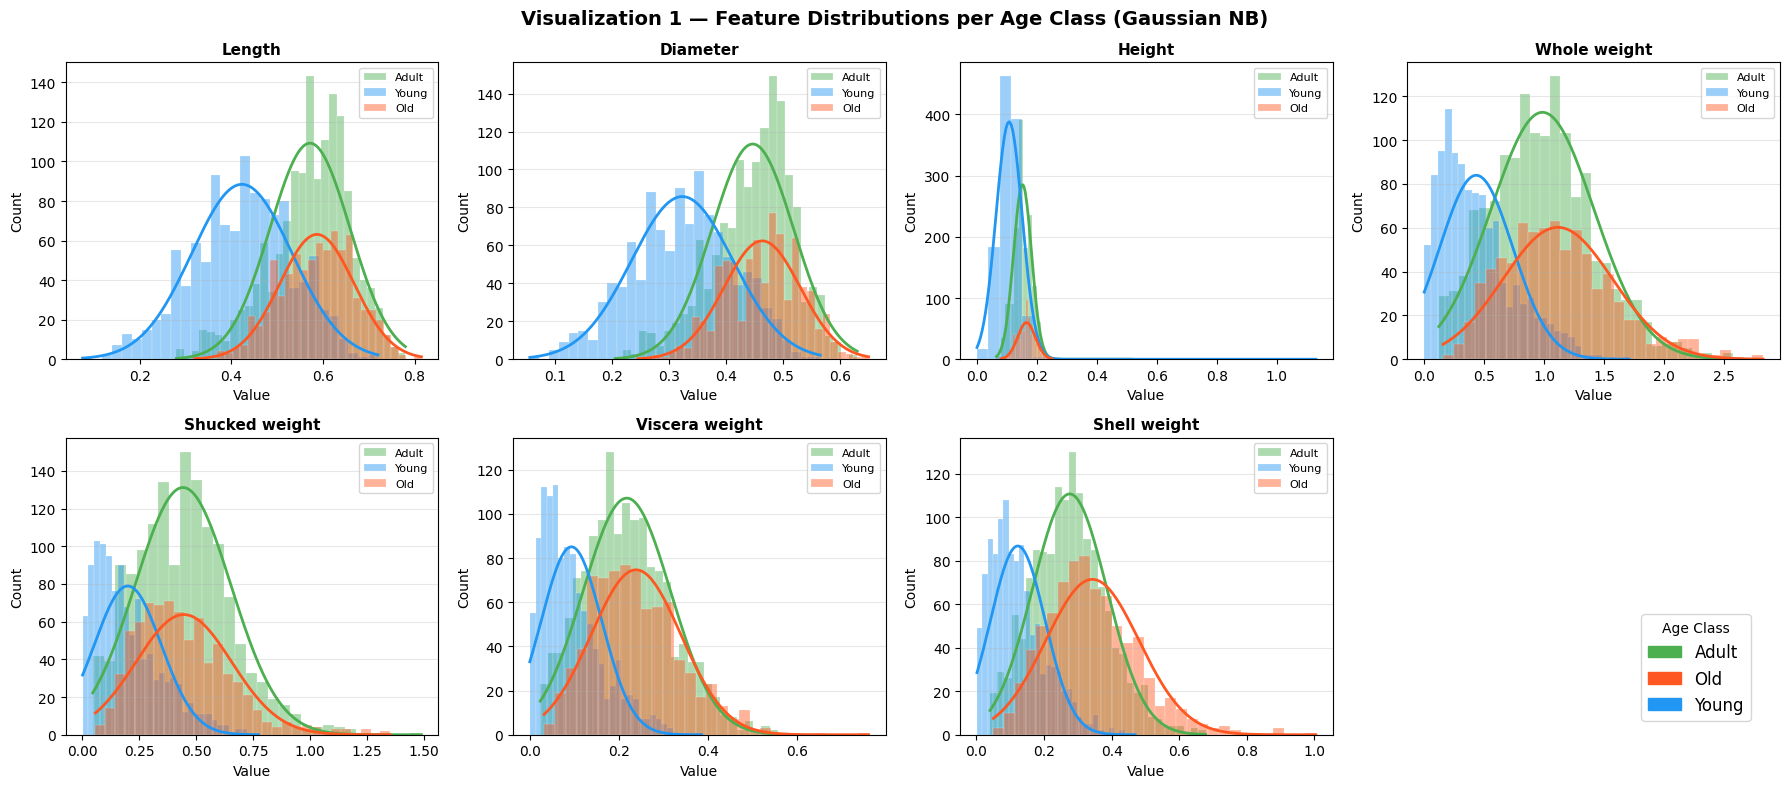

Saved: viz1_gnb_feature_distributions.png


In [ ]:
CLASS_COLORS = {'Young': '#2196F3', 'Adult': '#4CAF50', 'Old': '#FF5722'}
separated_np = {c: np.array(separated[c]) for c in classes_gnb}

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for f, feature in enumerate(FEATURE_COLS):
    ax = axes[f]
    for c in classes_gnb:
        col_vals = separated_np[c][:, f]
        ax.hist(col_vals, bins=30, alpha=0.45, color=CLASS_COLORS[c],
                label=c, edgecolor='white', linewidth=0.3)
        mu  = gnb_means[c][f]
        sig = math.sqrt(gnb_vars[c][f] + 1e-9)
        x_range  = np.linspace(col_vals.min(), col_vals.max(), 200)
        pdf_vals = [(1/(sig*math.sqrt(2*math.pi))) * math.exp(-0.5*((xi-mu)/sig)**2)
                    for xi in x_range]
        scale = len(col_vals) * (col_vals.max() - col_vals.min()) / 30
        ax.plot(x_range, np.array(pdf_vals)*scale, color=CLASS_COLORS[c], linewidth=2)
    ax.set_title(feature, fontsize=11, fontweight='bold')
    ax.set_xlabel('Value'); ax.set_ylabel('Count')
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

axes[7].set_visible(False)
patches = [mpatches.Patch(color=CLASS_COLORS[c], label=c) for c in sorted(CLASS_COLORS)]
fig.legend(handles=patches, loc='lower right', fontsize=12,
           title='Age Class', bbox_to_anchor=(0.98, 0.08))
fig.suptitle('Visualization 1 — Feature Distributions per Age Class (Gaussian NB)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz1_gnb_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz1_gnb_feature_distributions.png")

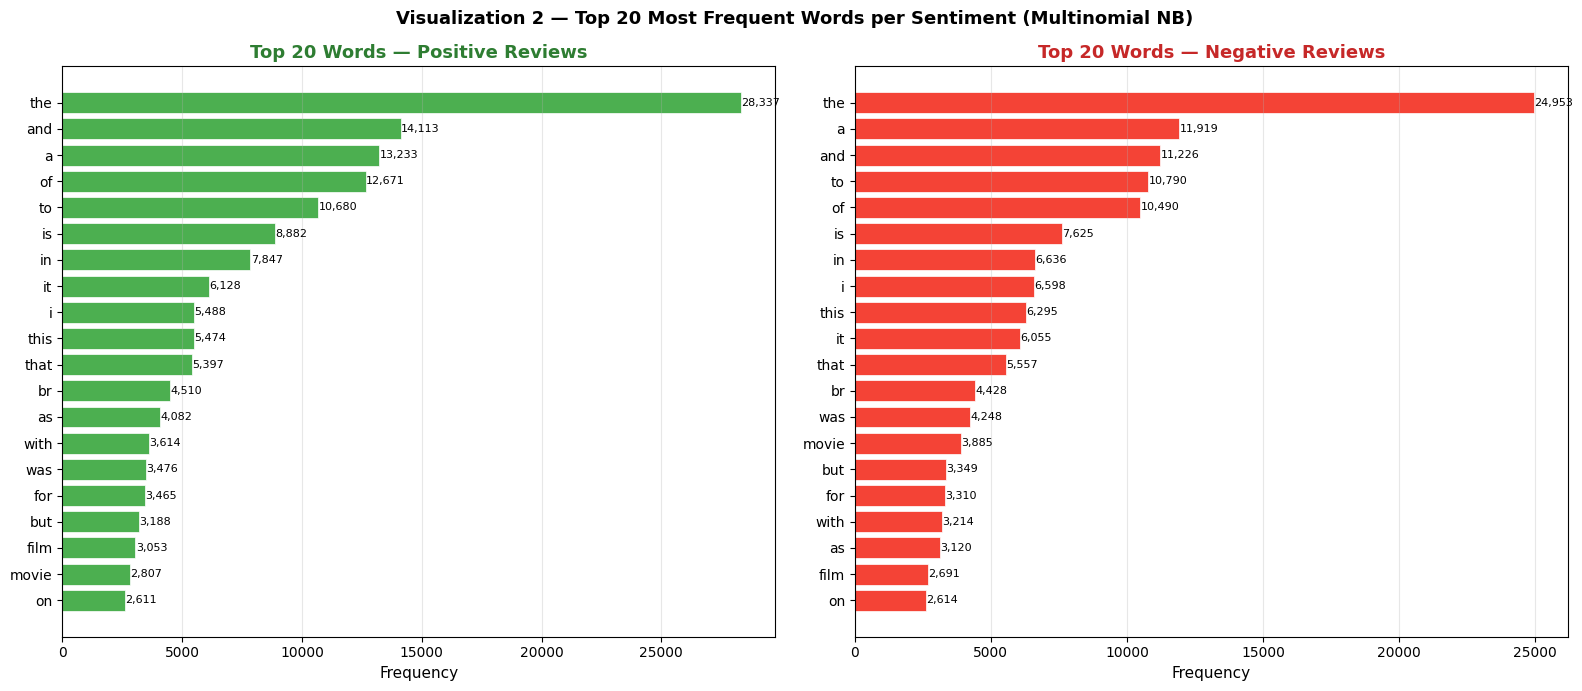

Saved: viz2_mnb_top_words.png


In [ ]:
class_word_counts = {0: {}, 1: {}}
for i, text in enumerate(train_texts):
    lbl = train_labels[i]
    for token in preprocess(text):
        class_word_counts[lbl][token] = class_word_counts[lbl].get(token, 0) + 1

def top_n_words(wc_dict, n=20):
    return sorted(wc_dict.items(), key=lambda x: x[1], reverse=True)[:n]

top_pos = top_n_words(class_word_counts[1], 20)
top_neg = top_n_words(class_word_counts[0], 20)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

words_pos, counts_pos = zip(*top_pos)
bars = ax1.barh(words_pos[::-1], counts_pos[::-1], color='#4CAF50', edgecolor='white', linewidth=0.5)
ax1.set_title('Top 20 Words — Positive Reviews', fontsize=13, fontweight='bold', color='#2E7D32')
ax1.set_xlabel('Frequency', fontsize=11); ax1.grid(axis='x', alpha=0.3)
for bar in bars:
    ax1.text(bar.get_width()+10, bar.get_y()+bar.get_height()/2,
             f'{int(bar.get_width()):,}', va='center', fontsize=8)

words_neg, counts_neg = zip(*top_neg)
bars = ax2.barh(words_neg[::-1], counts_neg[::-1], color='#F44336', edgecolor='white', linewidth=0.5)
ax2.set_title('Top 20 Words — Negative Reviews', fontsize=13, fontweight='bold', color='#C62828')
ax2.set_xlabel('Frequency', fontsize=11); ax2.grid(axis='x', alpha=0.3)
for bar in bars:
    ax2.text(bar.get_width()+10, bar.get_y()+bar.get_height()/2,
             f'{int(bar.get_width()):,}', va='center', fontsize=8)

fig.suptitle('Visualization 2 — Top 20 Most Frequent Words per Sentiment (Multinomial NB)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('viz2_mnb_top_words.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz2_mnb_top_words.png")

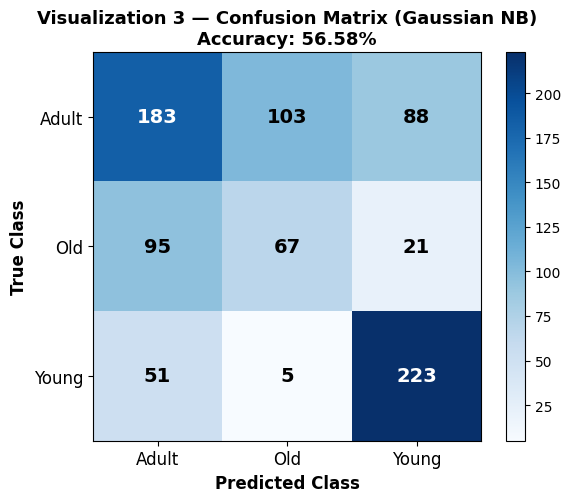

Saved: viz3_gnb_confusion_matrix.png


In [ ]:
def build_confusion_matrix(y_true, y_pred, class_labels):
    n = len(class_labels)
    label_to_idx = {c: i for i, c in enumerate(class_labels)}
    cm = [[0]*n for _ in range(n)]
    for t, p in zip(y_true, y_pred):
        cm[label_to_idx[t]][label_to_idx[p]] += 1
    return cm

gnb_labels  = sorted(set(y_test))
cm_gnb_arr  = np.array(build_confusion_matrix(y_test, y_pred_log, gnb_labels))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_gnb_arr, cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(gnb_labels))); ax.set_xticklabels(gnb_labels, fontsize=12)
ax.set_yticks(range(len(gnb_labels))); ax.set_yticklabels(gnb_labels, fontsize=12)
ax.set_xlabel('Predicted Class', fontsize=12, fontweight='bold')
ax.set_ylabel('True Class',      fontsize=12, fontweight='bold')
thresh = cm_gnb_arr.max() / 2
for i in range(len(gnb_labels)):
    for j in range(len(gnb_labels)):
        color = 'white' if cm_gnb_arr[i,j] > thresh else 'black'
        ax.text(j, i, str(cm_gnb_arr[i,j]), ha='center', va='center',
                color=color, fontsize=14, fontweight='bold')
ax.set_title(f'Visualization 3 — Confusion Matrix (Gaussian NB)\nAccuracy: {acc_log*100:.2f}%',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('viz3_gnb_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz3_gnb_confusion_matrix.png")

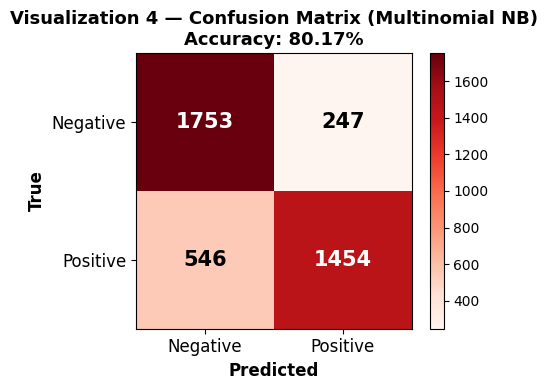

Saved: viz4_mnb_confusion_matrix.png


In [ ]:
mnb_labels      = [0, 1]
mnb_label_names = ['Negative', 'Positive']
cm_mnb_arr = np.array(build_confusion_matrix(
    y_test_imdb.tolist(), y_pred_mnb.tolist(), mnb_labels))

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_mnb_arr, cmap='Reds')
plt.colorbar(im, ax=ax)
ax.set_xticks([0,1]); ax.set_xticklabels(mnb_label_names, fontsize=12)
ax.set_yticks([0,1]); ax.set_yticklabels(mnb_label_names, fontsize=12)
ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
ax.set_ylabel('True',      fontsize=12, fontweight='bold')
thresh = cm_mnb_arr.max() / 2
for i in range(2):
    for j in range(2):
        color = 'white' if cm_mnb_arr[i,j] > thresh else 'black'
        ax.text(j, i, str(cm_mnb_arr[i,j]), ha='center', va='center',
                color=color, fontsize=15, fontweight='bold')
ax.set_title(f'Visualization 4 — Confusion Matrix (Multinomial NB)\nAccuracy: {acc_mnb*100:.2f}%',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('viz4_mnb_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz4_mnb_confusion_matrix.png")